# Projet 6 - Modélisation et suivi avec MLFlow

In [12]:
import mlflow
import re
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
df = pd.read_csv("data/processed_data.csv")
df.head()

,index,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,...,False,0.0,0.0,0.0,False,False,0.0,0.0,0.0,6.0
4,4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Classification")

mlflow.sklearn.autolog()

In [5]:
# Baseline model
params = {
    "max_iter": 1000,
    "class_weight": "balanced"
}

# Preprocessing
X = df.loc[df["TARGET"].notnull()].replace([np.inf, -np.inf], np.nan)
y = X["TARGET"].astype(int)
feats = [f for f in X.columns if f not in ["TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"]]
X_train, X_test, y_train, y_test = train_test_split(X[feats], y, test_size=0.2, random_state=0)

with mlflow.start_run():
    # --- context ---
    mlflow.set_tags({
        "data_version": "v1",
        "auteur": "Amaury",
    })

    # --- params ---
    mlflow.log_params(params)

    # --- training ---
    baseline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(**params)),
    ]).fit(X_train, y_train)

    proba = baseline.predict_proba(X_test)[:, 1]
    y_pred = baseline.predict(X_test)

    # --- metrics ---
    mlflow.log_metrics({
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, proba),
    })

2026/08/12 23:02:02 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/08/12 23:03:46 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Dev\Openclassrooms\Projet6\.venv\Lib\site

🏃 View run delightful-bug-20 at: http://localhost:5000/#/experiments/1/runs/32cbc2678d4146c6957d1b9e36af59f8
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [6]:
# Preprocessing
df.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", c) for c in df.columns]
cast = df.select_dtypes(include=["object", "bool"]).columns
df[cast] = df[cast].astype("float64")
X = df.loc[df["TARGET"].notnull()]
y = X["TARGET"].astype(int)
feats = [f for f in X.columns if f not in ["TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"]]
X_train, X_val, y_train, y_val = train_test_split(X[feats], y, test_size=0.25, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.2, random_state=0)

In [31]:
# LightGBM model
params = {
    "nthread": 4,
    "n_estimators": 10000,
    "learning_rate": 0.02,
    "num_leaves": 34,
    "colsample_bytree": 0.9497036,
    "subsample": 0.8715623,
    "max_depth": 8,
    "reg_alpha": 0.041545473,
    "reg_lambda": 0.0735294,
    "min_split_gain": 0.0222415,
    "min_child_weight": 39.3259775,
    "verbose": -1,
}

with mlflow.start_run():
    # --- params ---
    mlflow.log_params(params)

    # --- training ---
    clf = lgb.LGBMClassifier(**params).fit(
        X_train, y_train,
        eval_X=X_val, eval_y=y_val,
        eval_metric="auc",
        callbacks=[lgb.early_stopping(200, verbose=False)],
    )

    proba = clf.predict_proba(X_test)[:, 1]
    y_pred = clf.predict(X_test)

    # --- metrics ---
    mlflow.log_metrics({
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, proba),
    })

d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


🏃 View run able-owl-659 at: http://localhost:5000/#/experiments/1/runs/5b2e85bb39cc455e88213091f01a8f78
🧪 View experiment at: http://localhost:5000/#/experiments/1


## LightGBM + StratifiedKFold (validation croisée, façon kernel Aguiar)

Reprise de la fonction `kfold_lightgbm` du kernel Aguiar : entraînement de LightGBM sur `n_folds` plis stratifiés, prédictions *out-of-fold* (OOF) pour estimer l'AUC sur l'ensemble du train sans fuite, et moyenne des importances de variables. Adapté à l'API LightGBM récente (`callbacks`) et suivi dans MLFlow.

In [7]:
# --- données ---
train_df = df.loc[df["TARGET"].notnull()].reset_index(drop=True)
y = train_df["TARGET"].astype(int)
feats = [f for f in train_df.columns
         if f not in ["TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"]]

num_folds = 5
params = {
    "nthread": 4,
    "n_estimators": 10000,
    "learning_rate": 0.02,
    "num_leaves": 34,
    "colsample_bytree": 0.9497036,
    "subsample": 0.8715623,
    "max_depth": 8,
    "reg_alpha": 0.041545473,
    "reg_lambda": 0.0735294,
    "min_split_gain": 0.0222415,
    "min_child_weight": 39.3259775,
    "verbose": -1,
}

folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=1001)
oof_preds = np.zeros(train_df.shape[0])
feature_importance_df = pd.DataFrame()
fold_aucs = []

# autolog crée un run par fit -> on regroupe dans un run parent avec des runs imbriqués
mlflow.sklearn.autolog(disable=True)

with mlflow.start_run(run_name="lgbm_stratified_kfold"):
    mlflow.set_tags({"data_version": "v1", "auteur": "Amaury", "cv": f"StratifiedKFold_{num_folds}"})
    mlflow.log_params(params)
    mlflow.log_param("num_folds", num_folds)

    for n_fold, (train_idx, valid_idx) in enumerate(folds.split(train_df[feats], y)):
        train_x, train_y = train_df[feats].iloc[train_idx], y.iloc[train_idx]
        valid_x, valid_y = train_df[feats].iloc[valid_idx], y.iloc[valid_idx]

        clf = lgb.LGBMClassifier(**params)
        clf.fit(
            train_x, train_y,
            eval_set=[(train_x, train_y), (valid_x, valid_y)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)],
        )

        # prédictions out-of-fold à la meilleure itération
        oof_preds[valid_idx] = clf.predict_proba(
            valid_x, num_iteration=clf.best_iteration_
        )[:, 1]

        fold_auc = roc_auc_score(valid_y, oof_preds[valid_idx])
        fold_aucs.append(fold_auc)
        mlflow.log_metric("fold_auc", fold_auc, step=n_fold)
        print("Fold %2d AUC : %.6f" % (n_fold + 1, fold_auc))

        # importances des variables (moyennées sur les plis ensuite)
        fold_imp = pd.DataFrame({
            "feature": feats,
            "importance": clf.feature_importances_,
            "fold": n_fold + 1,
        })
        feature_importance_df = pd.concat([feature_importance_df, fold_imp], axis=0)

    full_auc = roc_auc_score(y, oof_preds)
    print("Full (OOF) AUC score : %.6f" % full_auc)

    mlflow.log_metrics({
        "oof_auc": full_auc,
        "cv_auc_mean": float(np.mean(fold_aucs)),
        "cv_auc_std": float(np.std(fold_aucs)),
    })

# Top 20 des variables les plus importantes (moyenne sur les plis)
top_features = (
    feature_importance_df.groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)
top_features

d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold  1 AUC : 0.785788


d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold  2 AUC : 0.791333


d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


...

d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold  4 AUC : 0.793808


d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold  5 AUC : 0.790670
Full (OOF) AUC score : 0.790988
🏃 View run lgbm_stratified_kfold at: http://localhost:5000/#/experiments/1/runs/61840218754c42e382157c33251b9a1c
🧪 View experiment at: http://localhost:5000/#/experiments/1


feature
PAYMENT_RATE                      1086.8
EXT_SOURCE_1                       985.0
EXT_SOURCE_3                       963.8
EXT_SOURCE_2                       908.0
DAYS_BIRTH                         707.6
AMT_ANNUITY                        536.4
DAYS_EMPLOYED                      514.0
APPROVED_CNT_PAYMENT_MEAN          440.0
DAYS_ID_PUBLISH                    423.2
INSTAL_DAYS_ENTRY_PAYMENT_MAX      412.8
ACTIVE_DAYS_CREDIT_MAX             402.0
ANNUITY_INCOME_PERC                395.8
DAYS_EMPLOYED_PERC                 391.0
INSTAL_DPD_MEAN                    388.8
DAYS_REGISTRATION                  369.4
ACTIVE_DAYS_CREDIT_ENDDATE_MIN     364.8
AMT_GOODS_PRICE                    347.8
AMT_CREDIT                         346.0
PREV_CNT_PAYMENT_MEAN              342.4
INSTAL_AMT_PAYMENT_SUM             319.6
Name: importance, dtype: float64

## Optimisation des hyperparamètres (Optuna) + seuil de décision métier

**Fonction de coût métier.** En scoring crédit, un **faux négatif** (mauvais payeur accepté → défaut de remboursement) coûte bien plus cher qu'un **faux positif** (bon client refusé → manque à gagner). On pondère donc :

$$\text{coût} = 10 \times FN + 1 \times FP$$

**Démarche :**
1. Optuna cherche les hyperparamètres LightGBM qui **minimisent ce coût métier** (et non l'AUC seule), estimé en validation croisée stratifiée *out-of-fold*.
2. Pour chaque jeu de paramètres, on cherche le **seuil de décision** (entre 0.02 et 0.90) qui minimise le coût — le seuil par défaut de 0.5 n'a aucune raison d'être optimal ici.
3. On trace la **courbe coût vs seuil** pour justifier le seuil retenu, et on logge le tout dans MLFlow.

In [8]:
# --- Fonction de coût métier et recherche du seuil optimal ---
import optuna
from sklearn.metrics import confusion_matrix

# Coût d'un faux négatif (mauvais payeur accepté) vs faux positif (bon client refusé)
COST_FN, COST_FP = 10, 1


def business_cost(y_true, y_pred, cost_fn=COST_FN, cost_fp=COST_FP):
    """Coût métier total : cost_fn * FN + cost_fp * FP."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return cost_fn * fn + cost_fp * fp


def best_threshold(y_true, proba, thresholds=None, cost_fn=COST_FN, cost_fp=COST_FP):
    """Renvoie (seuil optimal, coût min, grille de seuils, coûts) en minimisant le coût métier."""
    if thresholds is None:
        thresholds = np.arange(0.02, 0.90, 0.01)
    costs = np.array([
        business_cost(y_true, (proba >= t).astype(int), cost_fn, cost_fp)
        for t in thresholds
    ])
    i = int(costs.argmin())
    return float(thresholds[i]), float(costs[i]), thresholds, costs


# données d'entraînement (colonnes déjà nettoyées plus haut)
train_df = df.loc[df["TARGET"].notnull()].reset_index(drop=True)
y = train_df["TARGET"].astype(int)
feats = [f for f in train_df.columns
         if f not in ["TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"]]
X_all = train_df[feats]

In [ ]:
# --- Optimisation Optuna : minimiser le coût métier en CV stratifiée ---
# NB : cette cellule est longue (n_trials x n_folds entraînements LightGBM).
#      Réduire N_TRIALS / N_FOLDS_SEARCH pour un premier essai plus rapide.
N_TRIALS = 20
N_FOLDS_SEARCH = 3

optuna.logging.set_verbosity(optuna.logging.WARNING)
search_folds = StratifiedKFold(n_splits=N_FOLDS_SEARCH, shuffle=True, random_state=1001)


def objective(trial):
    params = {
        "objective": "binary",
        "n_estimators": 10000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 64),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 60.0),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.1),
        "n_jobs": 4,
        "verbose": -1,
    }
    oof = np.zeros(len(y))
    for tr_idx, va_idx in search_folds.split(X_all, y):
        clf = lgb.LGBMClassifier(**params)
        clf.fit(
            X_all.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X_all.iloc[va_idx], y.iloc[va_idx])],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
        )
        oof[va_idx] = clf.predict_proba(
            X_all.iloc[va_idx], num_iteration=clf.best_iteration_
        )[:, 1]

    thr, cost, _, _ = best_threshold(y, oof)
    trial.set_user_attr("best_threshold", thr)
    trial.set_user_attr("oof_auc", float(roc_auc_score(y, oof)))
    return cost  # objectif = coût métier à minimiser


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Meilleur coût métier (OOF) : %.0f" % study.best_value)
print("AUC OOF associée           : %.6f" % study.best_trial.user_attrs["oof_auc"])
print("Seuil associé              : %.3f" % study.best_trial.user_attrs["best_threshold"])
print("Meilleurs hyperparamètres  :")
study.best_params

  0%|          | 0/20 [00:00<?, ?it/s]d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
Best trial: 0. Best value: 149301:   5%|▌         | 1/20 [07:00<2:13:06, 420.33s/it]d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecat

d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(e

AUC OOF (best params)      : 0.791506
Seuil métier optimal       : 0.080
Coût au seuil optimal      : 148082
Coût au seuil 0.5          : 235858
Gain vs seuil 0.5          : 37.2 %


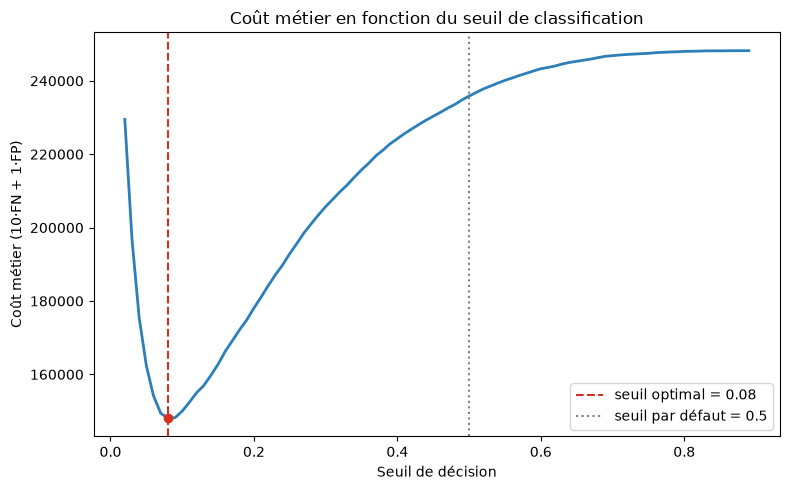

🏃 View run lgbm_optuna_seuil_metier at: http://localhost:5000/#/experiments/1/runs/b26e4832bee046a9ad236d9d4b3f2a05
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [ ]:
# --- Modèle final : meilleurs params + seuil métier + courbe coût vs seuil ---
import matplotlib.pyplot as plt

best_params = {
    **study.best_params,
    "objective": "binary",
    "n_estimators": 10000,
    "n_jobs": 4,
    "verbose": -1,
}

# OOF en 5 plis avec les meilleurs params -> seuil robuste + AUC honnête
final_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=1001)
oof_best = np.zeros(len(y))
best_iters = []
for tr_idx, va_idx in final_folds.split(X_all, y):
    clf = lgb.LGBMClassifier(**best_params)
    clf.fit(
        X_all.iloc[tr_idx], y.iloc[tr_idx],
        eval_set=[(X_all.iloc[va_idx], y.iloc[va_idx])],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)],
    )
    oof_best[va_idx] = clf.predict_proba(
        X_all.iloc[va_idx], num_iteration=clf.best_iteration_
    )[:, 1]
    best_iters.append(clf.best_iteration_)

opt_thr, opt_cost, thresholds, costs = best_threshold(y, oof_best)
oof_auc_best = roc_auc_score(y, oof_best)
cost_default = business_cost(y, (oof_best >= 0.5).astype(int))

print("AUC OOF (best params)      : %.6f" % oof_auc_best)
print("Seuil métier optimal       : %.3f" % opt_thr)
print("Coût au seuil optimal      : %.0f" % opt_cost)
print("Coût au seuil 0.5          : %.0f" % cost_default)
print("Gain vs seuil 0.5          : %.1f %%" % (100 * (cost_default - opt_cost) / cost_default))

# --- Courbe coût métier vs seuil ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, costs, lw=2, color="#2c7fb8")
ax.axvline(opt_thr, color="#d7301f", ls="--", label=f"seuil optimal = {opt_thr:.2f}")
ax.axvline(0.5, color="grey", ls=":", label="seuil par défaut = 0.5")
ax.scatter([opt_thr], [opt_cost], color="#d7301f", zorder=5)
ax.set_xlabel("Seuil de décision")
ax.set_ylabel(f"Coût métier ({COST_FN}·FN + {COST_FP}·FP)")
ax.set_title("Coût métier en fonction du seuil de classification")
ax.legend()
fig.tight_layout()
plt.show()

# --- Modèle final entraîné sur tout le train (n_estimators = itération moyenne des plis) ---
final_params = {**best_params, "n_estimators": int(np.mean(best_iters))}
final_model = lgb.LGBMClassifier(**final_params).fit(X_all, y)

# --- Suivi MLFlow ---
mlflow.sklearn.autolog(disable=True)
with mlflow.start_run(run_name="lgbm_optuna_seuil_metier"):
    mlflow.set_tags({"auteur": "Amaury", "optim": "optuna", "cv": "StratifiedKFold_5"})
    mlflow.log_params(final_params)
    mlflow.log_params({"cost_fn": COST_FN, "cost_fp": COST_FP, "decision_threshold": opt_thr})
    mlflow.log_metrics({
        "oof_auc": oof_auc_best,
        "business_cost_optimal": opt_cost,
        "business_cost_default_05": float(cost_default),
    })
    mlflow.log_figure(fig, "cout_vs_seuil.png")
    # flavor native LightGBM : évite la sérialisation skops (qui rejette Booster/LGBMClassifier)
    mlflow.lightgbm.log_model(final_model, name="model")

## Reprise depuis MLFlow, sans réentraîner

Les cellules ci-dessus coûtent plusieurs heures de calcul. Leur résultat est déjà dans MLFlow : le run `lgbm_optuna_seuil_metier` contient le **modèle entraîné**, ses **hyperparamètres** et le **seuil métier**.

Cette cellule les récupère et reconstitue les variables (`best_params`, `best_iters`, `opt_thr`, `champion_model`…) attendues par la suite du notebook. C'est exactement l'intérêt du tracking : après un redémarrage du kernel, on repart du modèle plutôt que de la recherche d'hyperparamètres.

**Prérequis** : avoir exécuté les cellules 1 à 3 (imports, chargement de `df`, connexion MLFlow), la cellule de nettoyage des colonnes et la cellule qui définit `X_all`, `y` et la fonction de coût.

Pour repartir de zéro à la place, sautez cette cellule et exécutez les cellules Optuna.


In [9]:
# --- Reprise : récupérer depuis MLFlow le modèle et les résultats déjà calculés ---
# Cellule autonome : elle reconstruit au besoin df, X_all, y et la fonction de coût.
# Seuls prérequis : la cellule d'imports et la cellule mlflow.set_tracking_uri().
import re
from mlflow import MlflowClient
from sklearn.metrics import confusion_matrix

# --- 0. Données (reconstruites seulement si elles ne sont pas déjà en mémoire) ---
if "df" not in globals():
    print("Chargement de data/processed_data.csv…")
    df = pd.read_csv("data/processed_data.csv")

# nettoyage des noms de colonnes + types : idempotent, sans effet si déjà fait
df.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", c) for c in df.columns]
cast = df.select_dtypes(include=["object", "bool"]).columns
if len(cast):
    df[cast] = df[cast].astype("float64")

train_df = df.loc[df["TARGET"].notnull()].reset_index(drop=True)
y = train_df["TARGET"].astype(int)
feats = [f for f in train_df.columns
         if f not in ["TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"]]
X_all = train_df[feats]

# --- 1. Fonction de coût métier (redéfinie ici pour que la cellule soit autonome) ---
COST_FN, COST_FP = 10, 1


def business_cost(y_true, y_pred, cost_fn=COST_FN, cost_fp=COST_FP):
    """Coût métier total : cost_fn * FN + cost_fp * FP."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return cost_fn * fn + cost_fp * fp


# --- 2. Run à reprendre (None = dernier run terminé portant ce nom) ---
RUN_SOURCE = None

client = MlflowClient()
if RUN_SOURCE is None:
    runs = client.search_runs(
        experiment_ids=[mlflow.get_experiment_by_name("Classification").experiment_id],
        filter_string="attributes.run_name = 'lgbm_optuna_seuil_metier' "
                      "and attributes.status = 'FINISHED'",
        order_by=["attributes.start_time DESC"],
        max_results=1,
    )
    if not runs:
        raise RuntimeError("Aucun run 'lgbm_optuna_seuil_metier' terminé : exécutez les "
                           "cellules Optuna, ou renseignez RUN_SOURCE.")
    RUN_SOURCE = runs[0].info.run_id

run_src = client.get_run(RUN_SOURCE)
p, m = run_src.data.params, run_src.data.metrics

# --- 3. Le modèle entraîné (LGBMClassifier complet, prêt à prédire) ---
champion_model = mlflow.lightgbm.load_model(f"runs:/{RUN_SOURCE}/model")

# garde-fou : les colonnes doivent correspondre exactement à celles de l'entraînement
if list(champion_model.feature_name_) != list(X_all.columns):
    manquantes = set(champion_model.feature_name_) - set(X_all.columns)
    raise RuntimeError(
        f"Colonnes incohérentes avec le modèle ({len(manquantes)} manquantes : "
        f"{sorted(manquantes)[:5]}…). Le fichier de données a-t-il changé ?")

# --- 4. Hyperparamètres, retypés (MLFlow stocke les paramètres en chaînes) ---
best_params = {
    "objective": "binary",
    "n_estimators": 10000,          # borne haute + early stopping si on réentraîne
    "learning_rate": float(p["learning_rate"]),
    "num_leaves": int(p["num_leaves"]),
    "max_depth": int(p["max_depth"]),
    "colsample_bytree": float(p["colsample_bytree"]),
    "subsample": float(p["subsample"]),
    "reg_alpha": float(p["reg_alpha"]),
    "reg_lambda": float(p["reg_lambda"]),
    "min_child_weight": float(p["min_child_weight"]),
    "min_split_gain": float(p["min_split_gain"]),
    "n_jobs": 4,
    "verbose": -1,
}

# --- 5. Nombre d'arbres retenu et résultats métier ---
best_iters = [int(p["n_estimators"])]        # np.mean(best_iters) redonne cette valeur
opt_thr = float(p["decision_threshold"])
opt_cost = float(m["business_cost_optimal"])
cost_default = float(m["business_cost_default_05"])
oof_auc_best = float(m["oof_auc"])

print("Repris du run %s" % RUN_SOURCE)
print("  données          : %d clients, %d variables" % (len(y), X_all.shape[1]))
print("  modèle           : LGBMClassifier, %d arbres" % champion_model.n_estimators)
print("  seuil métier     : %.3f" % opt_thr)
print("  AUC OOF          : %.6f" % oof_auc_best)
print("  coût métier      : %.0f (contre %.0f au seuil 0.5, soit %.1f %% de gain)"
      % (opt_cost, cost_default, 100 * (cost_default - opt_cost) / cost_default))

# --- 6. Contrôle : le modèle rechargé prédit bien ---
proba_controle = champion_model.predict_proba(X_all.head(5))[:, 1]
print("\nContrôle sur 5 clients — probabilités :", np.round(proba_controle, 4))
print("Décisions au seuil métier            :", (proba_controle >= opt_thr).astype(int))
print("TARGET réel                          :", y.head(5).tolist())


Repris du run b26e4832bee046a9ad236d9d4b3f2a05
  données          : 307507 clients, 795 variables
  modèle           : LGBMClassifier, 2550 arbres
  seuil métier     : 0.080
  AUC OOF          : 0.791506
  coût métier      : 148082 (contre 235858 au seuil 0.5, soit 37.2 % de gain)

Contrôle sur 5 clients — probabilités : [0.3635 0.0097 0.0271 0.0426 0.0784]
Décisions au seuil métier            : [1 0 0 0 0]
TARGET réel                          : [1, 0, 0, 0, 0]


d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


AUC hold-out                    : 0.791466  (OOF train : 0.791506)
Seuil retenu sur le train       : 0.090
Seuil optimal sur le hold-out   : 0.080  (écart : -0.010)
Coût hold-out au seuil retenu   : 29794  (0.484 / client)
Coût hold-out au seuil 0.5      : 47441  -> gain 37.2 %
Perte vs seuil oracle           : 0.59 %

--- Métriques métier sur le hold-out ---
                          stratégie  seuil  coût  coût/client   TP    FP   FN    TN  précision  recall     f1  taux_refus
 seuil métier (choisi sur le train)   0.09 29794       0.4844 3320 13344 1645 43193     0.1992  0.6687 0.3070      0.2710
               seuil par défaut 0.5   0.50 47441       0.7714  240   191 4725 56346     0.5568  0.0483 0.0890      0.0070
seuil optimal a posteriori (oracle)   0.08 29619       0.4816 3538 15349 1427 41188     0.1873  0.7126 0.2967      0.3071
          tout accepter (référence)   1.01 49650       0.8073    0     0 4965 56537     0.0000  0.0000 0.0000      0.0000
           tout refuser (réf

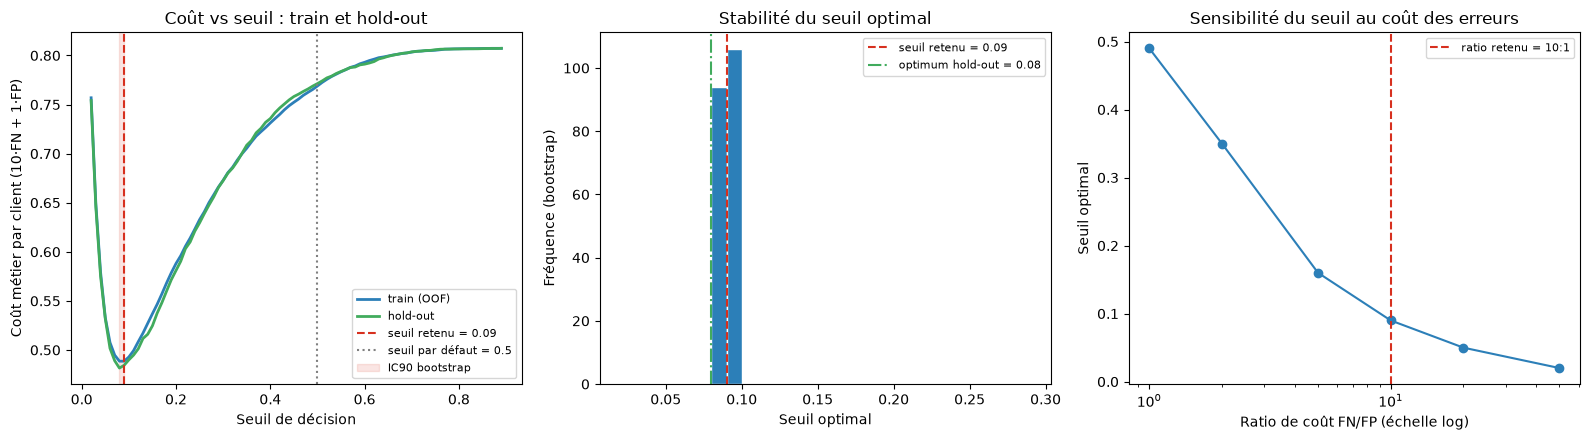

🏃 View run lgbm_robustesse_seuil_metier at: http://localhost:5000/#/experiments/1/runs/fe12dc398c7c4ff7a3ea53d5e0e4bb79
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [13]:
# --- Robustesse du modèle optimisé et du seuil métier ---
# Les hyperparamètres (Optuna) et le seuil ont été choisis sur les prédictions OOF de tout
# le train : un seuil qui "colle" à ces données pourrait ne pas tenir en production. On :
#   1. isole un hold-out jamais utilisé pour choisir quoi que ce soit ;
#   2. re-choisit le seuil uniquement sur le sous-train, puis on l'applique au hold-out ;
#   3. mesure la stabilité du seuil par bootstrap et sa sensibilité au ratio de coût FN/FP.

N_FOLDS_HO = 3        # plis de CV sur le sous-train (choix du seuil sans fuite)
N_BOOTSTRAP = 200     # rééchantillonnages pour l'intervalle du seuil optimal
THR_GRID = np.arange(0.02, 0.90, 0.01)   # grille plus large que 0.1-0.9 : avec ~8 % de
                                         # défauts et un coût FN/FP de 10:1, l'optimum
                                         # tombe sous 0.10, il faut pouvoir l'atteindre


def costs_on_grid(y_true, proba, grid=THR_GRID, cost_fn=COST_FN, cost_fp=COST_FP):
    """Coût métier sur toute la grille de seuils, en une passe (version vectorisée)."""
    y_true = np.asarray(y_true)
    pos = np.sort(proba[y_true == 1])
    neg = np.sort(proba[y_true == 0])
    n_fn = np.searchsorted(pos, grid, side="left")             # défauts acceptés (p < seuil)
    n_fp = len(neg) - np.searchsorted(neg, grid, side="left")  # bons clients refusés
    return cost_fn * n_fn + cost_fp * n_fp


def metriques_metier(y_true, proba, thr, libelle):
    """Métriques métier (coût, refus) et classiques à un seuil de décision donné."""
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    cout = COST_FN * fn + COST_FP * fp
    return {
        "stratégie": libelle,
        "seuil": thr,
        "coût": cout,
        "coût/client": cout / len(y_true),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "précision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "taux_refus": pred.mean(),
    }


# --- 1. Hold-out isolé -------------------------------------------------------
X_tr, X_ho, y_tr, y_ho = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=2024
)

# --- 2. Seuil choisi uniquement sur les OOF du sous-train --------------------
ho_folds = StratifiedKFold(n_splits=N_FOLDS_HO, shuffle=True, random_state=1001)
oof_tr = np.zeros(len(y_tr))
iters_ho = []
for tr_idx, va_idx in ho_folds.split(X_tr, y_tr):
    m = lgb.LGBMClassifier(**best_params)
    m.fit(
        X_tr.iloc[tr_idx], y_tr.iloc[tr_idx],
        eval_set=[(X_tr.iloc[va_idx], y_tr.iloc[va_idx])],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)],
    )
    oof_tr[va_idx] = m.predict_proba(
        X_tr.iloc[va_idx], num_iteration=m.best_iteration_
    )[:, 1]
    iters_ho.append(m.best_iteration_)

costs_tr = costs_on_grid(y_tr, oof_tr)
thr_tr = float(THR_GRID[costs_tr.argmin()])

# --- 3. Application au hold-out ---------------------------------------------
model_ho = lgb.LGBMClassifier(
    **{**best_params, "n_estimators": int(np.mean(iters_ho))}
).fit(X_tr, y_tr)
proba_ho = model_ho.predict_proba(X_ho)[:, 1]

costs_ho = costs_on_grid(y_ho, proba_ho)
thr_ho_oracle = float(THR_GRID[costs_ho.argmin()])   # seuil qu'on aurait choisi en trichant
auc_ho = roc_auc_score(y_ho, proba_ho)

comparaison = pd.DataFrame([
    metriques_metier(y_ho, proba_ho, thr_tr, "seuil métier (choisi sur le train)"),
    metriques_metier(y_ho, proba_ho, 0.5, "seuil par défaut 0.5"),
    metriques_metier(y_ho, proba_ho, thr_ho_oracle, "seuil optimal a posteriori (oracle)"),
    metriques_metier(y_ho, proba_ho, 1.01, "tout accepter (référence)"),
    metriques_metier(y_ho, proba_ho, 0.0, "tout refuser (référence)"),
])

cout_thr = comparaison.loc[0, "coût"]
cout_05 = comparaison.loc[1, "coût"]
print("AUC hold-out                    : %.6f  (OOF train : %.6f)" % (auc_ho, oof_auc_best))
print("Seuil retenu sur le train       : %.3f" % thr_tr)
print("Seuil optimal sur le hold-out   : %.3f  (écart : %+.3f)"
      % (thr_ho_oracle, thr_ho_oracle - thr_tr))
print("Coût hold-out au seuil retenu   : %.0f  (%.3f / client)"
      % (cout_thr, cout_thr / len(y_ho)))
print("Coût hold-out au seuil 0.5      : %.0f  -> gain %.1f %%"
      % (cout_05, 100 * (cout_05 - cout_thr) / cout_05))
print("Perte vs seuil oracle           : %.2f %%"
      % (100 * (cout_thr - comparaison.loc[2, "coût"]) / comparaison.loc[2, "coût"]))
print("\n--- Métriques métier sur le hold-out ---")
print(comparaison.round(4).to_string(index=False))

# --- 4. Stabilité du seuil (bootstrap sur les OOF du sous-train) -------------
rng = np.random.default_rng(0)
thr_boot = np.empty(N_BOOTSTRAP)
y_tr_arr = y_tr.to_numpy()
for b in range(N_BOOTSTRAP):
    idx = rng.integers(0, len(y_tr_arr), len(y_tr_arr))
    thr_boot[b] = THR_GRID[costs_on_grid(y_tr_arr[idx], oof_tr[idx]).argmin()]
thr_p05, thr_p95 = np.percentile(thr_boot, [5, 95])
print("\nSeuil optimal (bootstrap, n=%d) : médiane %.3f, IC90 [%.3f ; %.3f]"
      % (N_BOOTSTRAP, np.median(thr_boot), thr_p05, thr_p95))

# --- 5. Sensibilité au ratio de coût FN/FP ----------------------------------
lignes = []
for ratio in (1, 2, 5, 10, 20, 50):
    i = int(costs_on_grid(y_tr, oof_tr, cost_fn=ratio, cost_fp=1).argmin())
    c_ho = costs_on_grid(y_ho, proba_ho, cost_fn=ratio, cost_fp=1)
    lignes.append({
        "ratio_FN/FP": ratio,
        "seuil_optimal": float(THR_GRID[i]),
        "coût/client_hold-out": c_ho[i] / len(y_ho),
        "taux_refus_hold-out": float((proba_ho >= THR_GRID[i]).mean()),
    })
sensibilite = pd.DataFrame(lignes)
print("\n--- Sensibilité du seuil au ratio de coût ---")
print(sensibilite.round(4).to_string(index=False))

# --- 6. Visualisations ------------------------------------------------------
fig_rob, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(THR_GRID, costs_tr / len(y_tr), lw=2, color="#2c7fb8", label="train (OOF)")
ax.plot(THR_GRID, costs_ho / len(y_ho), lw=2, color="#41ab5d", label="hold-out")
ax.axvline(thr_tr, color="#d7301f", ls="--", label=f"seuil retenu = {thr_tr:.2f}")
ax.axvline(0.5, color="grey", ls=":", label="seuil par défaut = 0.5")
ax.axvspan(thr_p05, thr_p95, color="#d7301f", alpha=0.12, label="IC90 bootstrap")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel(f"Coût métier par client ({COST_FN}·FN + {COST_FP}·FP)")
ax.set_title("Coût vs seuil : train et hold-out")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(thr_boot, bins=np.arange(THR_GRID[0], 0.30, 0.01), color="#2c7fb8", edgecolor="white")
ax.axvline(thr_tr, color="#d7301f", ls="--", label=f"seuil retenu = {thr_tr:.2f}")
ax.axvline(thr_ho_oracle, color="#41ab5d", ls="-.", label=f"optimum hold-out = {thr_ho_oracle:.2f}")
ax.set_xlabel("Seuil optimal")
ax.set_ylabel("Fréquence (bootstrap)")
ax.set_title("Stabilité du seuil optimal")
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(sensibilite["ratio_FN/FP"], sensibilite["seuil_optimal"], "o-", color="#2c7fb8")
ax.axvline(COST_FN / COST_FP, color="#d7301f", ls="--", label=f"ratio retenu = {COST_FN}:{COST_FP}")
ax.set_xscale("log")
ax.set_xlabel("Ratio de coût FN/FP (échelle log)")
ax.set_ylabel("Seuil optimal")
ax.set_title("Sensibilité du seuil au coût des erreurs")
ax.legend(fontsize=8)

fig_rob.tight_layout()
plt.show()

# --- 7. Suivi MLFlow --------------------------------------------------------
mlflow.sklearn.autolog(disable=True)
with mlflow.start_run(run_name="lgbm_robustesse_seuil_metier"):
    mlflow.set_tags({"auteur": "Amaury", "etape": "robustesse", "validation": "hold-out 20%"})
    mlflow.log_params({**best_params, "n_estimators": int(np.mean(iters_ho))})
    mlflow.log_params({
        "cost_fn": COST_FN,
        "cost_fp": COST_FP,
        "decision_threshold": thr_tr,
        "n_folds_seuil": N_FOLDS_HO,
        "n_bootstrap": N_BOOTSTRAP,
    })
    mlflow.log_metrics({
        "holdout_auc": float(auc_ho),
        "holdout_cost": float(cout_thr),
        "holdout_cost_per_client": float(cout_thr / len(y_ho)),
        "holdout_cost_default_05": float(cout_05),
        "holdout_precision": float(comparaison.loc[0, "précision"]),
        "holdout_recall": float(comparaison.loc[0, "recall"]),
        "holdout_f1": float(comparaison.loc[0, "f1"]),
        "holdout_refusal_rate": float(comparaison.loc[0, "taux_refus"]),
        "threshold_holdout_oracle": thr_ho_oracle,
        "threshold_boot_p05": float(thr_p05),
        "threshold_boot_p95": float(thr_p95),
    })
    mlflow.log_figure(fig_rob, "robustesse_seuil.png")
    mlflow.log_table(comparaison, "comparaison_seuils_holdout.json")
    mlflow.log_table(sensibilite, "sensibilite_ratio_cout.json")


## Comparaison rigoureuse de plusieurs familles de modèles

La baseline de la cellule 4 (régression logistique) n'était **pas comparable** au LightGBM : autre découpage, autre préprocessing, pas de validation croisée, pas de coût métier. On reprend donc la comparaison dans un **protocole strictement identique pour tous les modèles** :

- même sous-échantillon stratifié, mêmes plis (`StratifiedKFold`), prédictions *out-of-fold* ;
- mêmes métriques : AUC, accuracy, précision, **recall sur la classe minoritaire**, F1 et **coût métier** ;
- **seuil ré-optimisé pour chaque modèle** sur le coût métier — comparer tout le monde à 0.5 avantagerait mécaniquement les modèles pondérés.

**Traitement du déséquilibre** (~8 % de défauts), explicite pour chaque famille :

| Modèle | Traitement du déséquilibre |
|---|---|
| Régression logistique | `class_weight="balanced"` |
| Random Forest | `class_weight="balanced_subsample"` |
| LightGBM « défaut » | aucun — sert de témoin |
| LightGBM pondéré | `scale_pos_weight` = ratio négatifs / positifs |
| LightGBM Optuna | hyperparamètres optimisés directement sur le coût métier |
| MLP | `MLPClassifier` n'expose pas de pondération → compensé par le seuil métier |

**Choix des fonctions d'activation du MLP.** `relu` sur les couches cachées : pas de saturation du gradient (contrairement à `logistic`/`tanh`, qui écrasent le gradient sur des entrées standardisées à large support) et convergence nettement plus rapide. En sortie, `MLPClassifier` applique une **sigmoïde** en classification binaire : c'est exactement ce qu'il nous faut, puisque toute la décision métier repose sur un **seuil appliqué à une probabilité** — une sortie non bornée serait inexploitable ici.


Sous-échantillon : 60000 clients, 8.07 % de défauts, ratio négatifs/positifs = 11.4
🏃 View run LogisticRegression (balanced) at: http://localhost:5000/#/experiments/1/runs/7894e2063af74fafb2eeac2922da51c0
🧪 View experiment at: http://localhost:5000/#/experiments/1
LogisticRegression (balanced)    AUC 0.7425 | recall 0.650 | coût/client 0.5467 |    17 s
🏃 View run RandomForest (balanced) at: http://localhost:5000/#/experiments/1/runs/5ef17cff2f534ea7b41c7ade6c0e92d1
🧪 View experiment at: http://localhost:5000/#/experiments/1
RandomForest (balanced)          AUC 0.7325 | recall 0.607 | coût/client 0.5644 |    30 s
🏃 View run MLP relu (64, 32) at: http://localhost:5000/#/experiments/1/runs/8c7bc2b5fb1b4bc09f57e8085effab7e
🧪 View experiment at: http://localhost:5000/#/experiments/1
MLP relu (64, 32)                AUC 0.7176 | recall 0.573 | coût/client 0.5810 |    21 s
🏃 View run LightGBM (sans pondération) at: http://localhost:5000/#/experiments/1/runs/48b08f7539a1456ab71ccebc330424da
🧪 

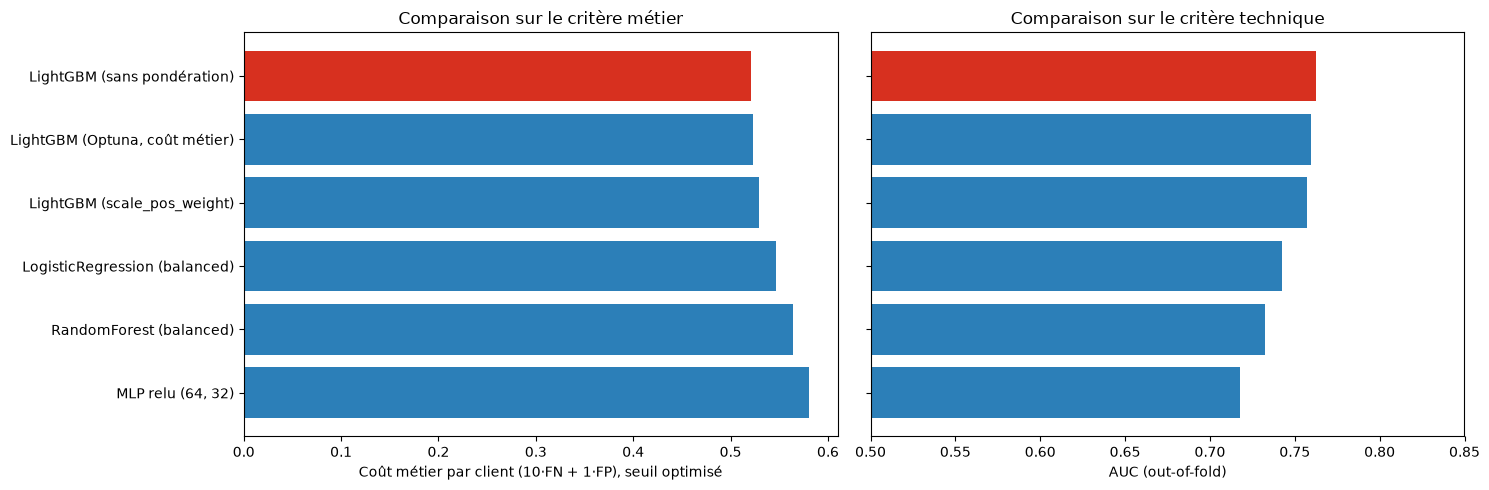

🏃 View run comparaison_modeles at: http://localhost:5000/#/experiments/1/runs/6480217d8f8a4601bb8af2be543a14fc
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [15]:
# --- Comparaison multi-modèles : même protocole pour tout le monde ---
# NB : Random Forest, MLP et régression logistique ne passent pas à l'échelle sur
#      307k x 795 en un temps raisonnable -> on compare sur un sous-échantillon
#      stratifié (le classement des familles reste valable).
import time
from sklearn.base import clone
from sklearn.neural_network import MLPClassifier

N_SAMPLE = 60_000
N_FOLDS_CMP = 3

X_cmp, _, y_cmp, _ = train_test_split(
    X_all, y, train_size=N_SAMPLE, stratify=y, random_state=0
)
# inf -> NaN (fatal pour les modèles linéaires / MLP) et float32 pour la mémoire
X_cmp = X_cmp.replace([np.inf, -np.inf], np.nan).astype("float32").reset_index(drop=True)
y_cmp = y_cmp.reset_index(drop=True)

ratio_desequilibre = float((y_cmp == 0).sum() / (y_cmp == 1).sum())
print("Sous-échantillon : %d clients, %.2f %% de défauts, ratio négatifs/positifs = %.1f"
      % (len(y_cmp), 100 * y_cmp.mean(), ratio_desequilibre))

modeles = {
    "LogisticRegression (balanced)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "RandomForest (balanced)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=200, max_depth=12, min_samples_leaf=20,
            class_weight="balanced_subsample", n_jobs=4, random_state=0)),
    ]),
    "MLP relu (64, 32)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(64, 32), activation="relu", alpha=1e-3,
            early_stopping=True, max_iter=60, random_state=0)),
    ]),
    "LightGBM (sans pondération)": lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.02, num_leaves=34, max_depth=8,
        n_jobs=4, verbose=-1),
    "LightGBM (scale_pos_weight)": lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.02, num_leaves=34, max_depth=8,
        scale_pos_weight=ratio_desequilibre, n_jobs=4, verbose=-1),
    "LightGBM (Optuna, coût métier)": lgb.LGBMClassifier(
        **{**best_params, "n_estimators": int(np.mean(best_iters))}),
}

cmp_folds = StratifiedKFold(n_splits=N_FOLDS_CMP, shuffle=True, random_state=1001)
resultats, oof_par_modele = [], {}

# MLFlow refuse les noms de métriques contenant @ ou des parenthèses : on garde des
# libellés lisibles dans le tableau et on logge sous des noms ASCII.
NOMS_MLFLOW = {
    "AUC": "auc",
    "accuracy": "accuracy",
    "précision": "precision",
    "recall": "recall",
    "f1": "f1",
    "seuil": "threshold",
    "coût/client": "cost_per_client",
    "coût/client @0.5": "cost_per_client_at_05",
    "durée (s)": "duration_s",
}

# si une exécution précédente s'est interrompue, le run resté ouvert bloquerait celle-ci
if mlflow.active_run():
    mlflow.end_run()

mlflow.sklearn.autolog(disable=True)
with mlflow.start_run(run_name="comparaison_modeles"):
    mlflow.set_tags({"auteur": "Amaury", "etape": "comparaison",
                     "cv": f"StratifiedKFold_{N_FOLDS_CMP}"})
    mlflow.log_params({"n_sample": N_SAMPLE, "n_folds": N_FOLDS_CMP,
                       "cost_fn": COST_FN, "cost_fp": COST_FP})

    for nom, modele in modeles.items():
        t0 = time.time()
        oof = np.zeros(len(y_cmp))
        for tr_idx, va_idx in cmp_folds.split(X_cmp, y_cmp):
            m = clone(modele)
            m.fit(X_cmp.iloc[tr_idx], y_cmp.iloc[tr_idx])
            oof[va_idx] = m.predict_proba(X_cmp.iloc[va_idx])[:, 1]
        duree = time.time() - t0

        # seuil ré-optimisé pour CHAQUE modèle sur le coût métier
        cout_grille = costs_on_grid(y_cmp, oof)
        i = int(cout_grille.argmin())
        thr = float(THR_GRID[i])
        pred = (oof >= thr).astype(int)

        res = {
            "modèle": nom,
            "AUC": roc_auc_score(y_cmp, oof),
            "accuracy": accuracy_score(y_cmp, pred),
            "précision": precision_score(y_cmp, pred, zero_division=0),
            "recall": recall_score(y_cmp, pred, zero_division=0),
            "f1": f1_score(y_cmp, pred, zero_division=0),
            "seuil": thr,
            "coût/client": cout_grille[i] / len(y_cmp),
            "coût/client @0.5": business_cost(y_cmp, (oof >= 0.5).astype(int)) / len(y_cmp),
            "durée (s)": duree,
        }
        resultats.append(res)
        oof_par_modele[nom] = oof

        with mlflow.start_run(run_name=nom, nested=True):
            mlflow.set_tags({"auteur": "Amaury", "famille": nom.split(" ")[0]})
            mlflow.log_metrics({NOMS_MLFLOW[k]: float(v)
                                for k, v in res.items() if k != "modèle"})

        print("%-32s AUC %.4f | recall %.3f | coût/client %.4f | %5.0f s"
              % (nom, res["AUC"], res["recall"], res["coût/client"], duree))

    comparaison_modeles = (pd.DataFrame(resultats)
                           .sort_values("coût/client")
                           .reset_index(drop=True))
    champion = comparaison_modeles.loc[0, "modèle"]

    print("\n--- Classement par coût métier (le plus bas gagne) ---")
    print(comparaison_modeles.round(4).to_string(index=False))
    print("\nModèle champion : %s" % champion)

    # --- Graphique comparatif : coût métier vs AUC ---
    fig_cmp, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ordre = comparaison_modeles["modèle"]
    couleurs = ["#d7301f" if m == champion else "#2c7fb8" for m in ordre]

    ax1.barh(ordre, comparaison_modeles["coût/client"], color=couleurs)
    ax1.invert_yaxis()
    ax1.set_xlabel(f"Coût métier par client ({COST_FN}·FN + {COST_FP}·FP), seuil optimisé")
    ax1.set_title("Comparaison sur le critère métier")

    ax2.barh(ordre, comparaison_modeles["AUC"], color=couleurs)
    ax2.invert_yaxis()
    ax2.set_xlim(0.5, 0.85)
    ax2.set_xlabel("AUC (out-of-fold)")
    ax2.set_title("Comparaison sur le critère technique")
    ax2.set_yticklabels([])

    fig_cmp.tight_layout()
    plt.show()

    mlflow.log_figure(fig_cmp, "comparaison_modeles.png")
    mlflow.log_table(comparaison_modeles, "comparaison_modeles.json")
    mlflow.log_metric("meilleur_cout_par_client", float(comparaison_modeles.loc[0, "coût/client"]))
    mlflow.set_tag("champion", champion)


## Modèle champion : enregistrement dans le Model Registry

Le modèle retenu est réentraîné sur **l'intégralité du train** puis versionné dans le **Model Registry** MLFlow, avec :

- une **signature** et un exemple d'entrée (contrat d'interface pour le serving) ;
- l'alias **`@champion`**, qui permet de référencer le modèle en production (`models:/credit_scoring_lgbm@champion`) sans coder en dur un numéro de version ;
- le **seuil métier** stocké en tag de version : le modèle renvoie une probabilité, la décision d'octroi n'a de sens qu'avec le seuil qui l'accompagne. Les deux doivent voyager ensemble.


In [16]:
# --- Modèle champion : enregistrement au Model Registry ---
import sklearn
from mlflow import MlflowClient
from mlflow.models import infer_signature

NOM_MODELE = "credit_scoring_lgbm"
SEUIL_PROD = float(opt_thr)   # seuil métier retenu

champion_params = {**best_params, "n_estimators": int(np.mean(best_iters))}

# Le modèle vient soit de la cellule « Reprise » (rechargé depuis MLFlow), soit d'un
# entraînement complet. Dans les deux cas, aucun réentraînement inutile ici.
if "champion_model" in globals():
    print("Modèle déjà disponible en mémoire (repris de MLFlow) — pas de réentraînement.")
else:
    print("Aucun modèle en mémoire : entraînement sur l'intégralité du train…")
    champion_model = lgb.LGBMClassifier(**champion_params).fit(X_all, y)


class ScoringCredit(mlflow.pyfunc.PythonModel):
    """Modèle servi : probabilité de défaut ET décision au seuil métier.

    Point clé : le flavor LightGBM natif appelle `LGBMClassifier.predict()`, qui
    tranche à 0.5 — précisément le seuil que tout ce travail vise à remplacer. On
    encapsule donc le modèle et son seuil pour que le service exposé prenne la
    décision métier, et non une décision par défaut.
    """

    def __init__(self, model, seuil):
        self.model = model
        self.seuil = seuil

    def predict(self, context, model_input, params=None):
        proba = self.model.predict_proba(model_input)[:, 1]
        return pd.DataFrame({
            "probabilite_defaut": proba,
            "decision": (proba >= self.seuil).astype(int),  # 1 = crédit refusé
            "seuil_applique": self.seuil,
        })


scoring = ScoringCredit(champion_model, SEUIL_PROD)

# Signature en float64 : les colonnes entières ne peuvent pas porter de NaN à
# l'inférence, ce qui ferait échouer la validation de schéma au serving.
exemple = X_all.head(5).astype("float64")
signature = infer_signature(exemple, scoring.predict(None, exemple))

# Les métriques de robustesse ne sont ajoutées que si la cellule correspondante a tourné
metriques_champion = {"oof_auc": float(oof_auc_best),
                      "business_cost_optimal": float(opt_cost)}
if "auc_ho" in globals():
    metriques_champion["holdout_auc"] = float(auc_ho)
    metriques_champion["holdout_cost_per_client"] = float(cout_thr / len(y_ho))

mlflow.sklearn.autolog(disable=True)
with mlflow.start_run(run_name="champion_credit_scoring") as run:
    mlflow.set_tags({
        "auteur": "Amaury",
        "etape": "champion",
        "modele": "LightGBM (Optuna, coût métier)",
        "data_version": "v1",
    })
    mlflow.log_params(champion_params)
    mlflow.log_params({"cost_fn": COST_FN, "cost_fp": COST_FP,
                       "decision_threshold": SEUIL_PROD, "n_features": X_all.shape[1]})
    mlflow.log_metrics(metriques_champion)

    # modèle servi (décision métier incluse) -> c'est lui qu'on enregistre au registry
    mlflow.pyfunc.log_model(
        name="model",
        python_model=scoring,
        signature=signature,
        input_example=exemple,
        pip_requirements=[
            f"lightgbm=={lgb.__version__}",
            f"scikit-learn=={sklearn.__version__}",
            f"pandas=={pd.__version__}",
            f"numpy=={np.__version__}",
        ],
        registered_model_name=NOM_MODELE,   # <- crée / incrémente la version au registry
    )
    # modèle brut également conservé (réutilisable pour SHAP, réentraînement…)
    mlflow.lightgbm.log_model(champion_model, name="model_lgbm_brut")
    run_id = run.info.run_id

# --- Alias, tags et description de la version enregistrée ---
client = MlflowClient()
version = max(int(v.version) for v in client.search_model_versions(f"name='{NOM_MODELE}'"))

client.set_registered_model_alias(NOM_MODELE, "champion", version)
client.set_model_version_tag(NOM_MODELE, version, "seuil_metier", f"{SEUIL_PROD:.3f}")
client.set_model_version_tag(NOM_MODELE, version, "ratio_cout_fn_fp", f"{COST_FN}:{COST_FP}")
if "auc_ho" in globals():
    client.set_model_version_tag(NOM_MODELE, version, "auc_holdout", f"{auc_ho:.4f}")

client.update_model_version(
    NOM_MODELE, version,
    description=(
        f"LightGBM optimisé par Optuna sur le coût métier ({COST_FN}·FN + {COST_FP}·FP). "
        f"Le modèle renvoie la probabilité de défaut ET la décision au seuil "
        f"{SEUIL_PROD:.3f} (et non 0.5) : crédit refusé si proba >= {SEUIL_PROD:.3f}. "
        f"AUC out-of-fold {oof_auc_best:.4f}. Entraîné sur {len(y)} clients, "
        f"{X_all.shape[1]} variables."
    ),
)
client.update_registered_model(
    NOM_MODELE,
    description="Modèle de scoring crédit « Prêt à dépenser ». L'alias @champion pointe "
                "toujours vers la version en service ; le seuil métier est en tag de version.",
)

print("\nModèle enregistré : %s version %d (alias @champion)" % (NOM_MODELE, version))
print("URI de production : models:/%s@champion" % NOM_MODELE)
print("Seuil métier      : %.3f" % SEUIL_PROD)
print("Run source        : %s" % run_id)

# --- Vérification : relecture depuis le registry ---
modele_prod = mlflow.pyfunc.load_model(f"models:/{NOM_MODELE}@champion")
print("\nRelecture depuis le registry OK :")
print(modele_prod.predict(exemple).round(4).to_string(index=False))


Modèle déjà disponible en mémoire (repris de MLFlow) — pas de réentraînement.


d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
d:\Dev\Openclassrooms\Projet6\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values

🏃 View run champion_credit_scoring at: http://localhost:5000/#/experiments/1/runs/ad36e6ef5e2e42d5bdff11b3ee26f9aa
🧪 View experiment at: http://localhost:5000/#/experiments/1

Modèle enregistré : credit_scoring_lgbm version 1 (alias @champion)
URI de production : models:/credit_scoring_lgbm@champion
Seuil métier      : 0.080
Run source        : ad36e6ef5e2e42d5bdff11b3ee26f9aa



Relecture depuis le registry OK :
 probabilite_defaut  decision  seuil_applique
             0.3635         1            0.08
             0.0097         0            0.08
             0.0271         0            0.08
             0.0426         0            0.08
             0.0784         0            0.08


## Serving MLFlow

Dernière brique MLOps demandée : exposer le modèle du registry derrière une API REST.

```bash
# terminal 1 — serveur de tracking + registry
poetry run mlflow server --backend-store-uri sqlite:///mlflow.db --port 5000

# terminal 2 — serving du modèle champion (l'alias évite de coder une version en dur)
$env:MLFLOW_TRACKING_URI = "http://localhost:5000"
poetry run mlflow models serve -m "models:/credit_scoring_lgbm@champion" --port 5001 --env-manager local
```

La cellule suivante envoie une requête réelle à `http://127.0.0.1:5001/invocations` et vérifie que la réponse contient bien la **probabilité de défaut et la décision au seuil métier**. Le même test est disponible en script autonome : [`test_serving.py`](test_serving.py).


In [17]:
# --- Test du serving : appel REST réel au modèle servi ---
import json
import requests

URL_SERVING = "http://127.0.0.1:5001/invocations"

# 5 clients du jeu de données, dont le premier est un défaut connu (TARGET = 1)
clients = X_all.head(5).astype("float64")
payload = {"dataframe_split": {
    "columns": clients.columns.tolist(),
    # astype(object) + None -> des `null` JSON valides plutôt que des jetons NaN
    "data": clients.astype(object).where(pd.notnull(clients), None).values.tolist(),
}}

# on garde une trace de la requête (utile pour rejouer le test hors notebook)
with open("data/exemple_requete.json", "w", encoding="utf-8") as f:
    json.dump(payload, f)

try:
    reponse = requests.post(URL_SERVING, json=payload, timeout=30)
    reponse.raise_for_status()
    predictions = pd.DataFrame(reponse.json()["predictions"])
    predictions.insert(0, "TARGET_réel", y.head(5).values)
    print("Réponse du serveur de serving (%s) :\n" % URL_SERVING)
    print(predictions.round(4).to_string(index=False))
    print("\n1 = crédit refusé. La décision vient du seuil métier %.3f embarqué dans le "
          "modèle, et non du 0.5 par défaut." % SEUIL_PROD)
except requests.exceptions.ConnectionError:
    print("Aucun serveur sur %s.\nLancez d'abord :\n"
          "  mlflow models serve -m \"models:/%s@champion\" --port 5001 --env-manager local"
          % (URL_SERVING, NOM_MODELE))


Aucun serveur sur http://127.0.0.1:5001/invocations.
Lancez d'abord :
  mlflow models serve -m "models:/credit_scoring_lgbm@champion" --port 5001 --env-manager local
